# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Rafi Razzan Arelian
- **Email:** rafirazzanarelian@mail.ugm.ac.id
- **ID Dicoding:**  CDCC008D6Y2713

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan 1:** Bagaimana tren rata-rata konsentrasi PM2.5 per tahun pada seluruh stasiun pengamatan di Beijing selama periode 2013–2017, serta pada tahun berapa terjadi tingkat polusi tertinggi?

**Keterangan:**
- **Specific:** Fokus pada tren PM2.5 di seluruh stasiun di Beijing.
- **Measurable:** Menggunakan rata-rata konsentrasi PM2.5 per tahun.
- **Action-Oriented:** Dapat digunakan untuk menentukan periode dengan polusi tinggi sehingga bisa dilakukan tindakan mitigasi.
- **Relevant:** Polusi udara merupakan isu penting yang berdampak pada kesehatan masyarakat.
- **Time-bound:** Terbatas pada periode 2013–2017.


**Pertanyaan 2:** Seberapa besar pengaruh variabel cuaca (suhu, tekanan udara, dan kecepatan angin) terhadap variasi konsentrasi PM2.5 selama periode 2013–2017?

**Keterangan:**
- **Specific:** Fokus pada hubungan antara variabel cuaca dan PM2.5.
- **Measurable:** Dapat diukur menggunakan korelasi.
- **Action-Oriented:** Hasilnya dapat digunakan untuk memahami faktor lingkungan yang memengaruhi polusi udara.
- **Relevant:** Faktor cuaca berperan dalam penyebaran dan konsentrasi polutan.
- **Time-bound:** Terbatas pada periode 2013–2017.

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
files = glob.glob("PRSA_Data_*.csv")
df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou


**Insight:** (Opsional)
- Dataset terdiri dari beberapa variabel penting seperti polutan (PM2.5, PM10, SO2, NO2, CO, O3) serta variabel cuaca (TEMP, PRES, DEWP, RAIN, WSPM) dan informasi stasiun.
- Terlihat sudah terdapat **missing values (NaN)** pada beberapa kolom seperti PM2.5, NO2, CO, dan O3 bahkan dari baris awal data.
- Dataset memiliki struktur **time-series** dengan kolom year, month, day, dan hour yang merepresentasikan waktu pengamatan.
- Setiap baris merepresentasikan satu waktu pengamatan pada satu stasiun tertentu (contoh: Huairou).

### Assessing Data

#### Identifying ... problem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
Missing Values:
 No             0
year       

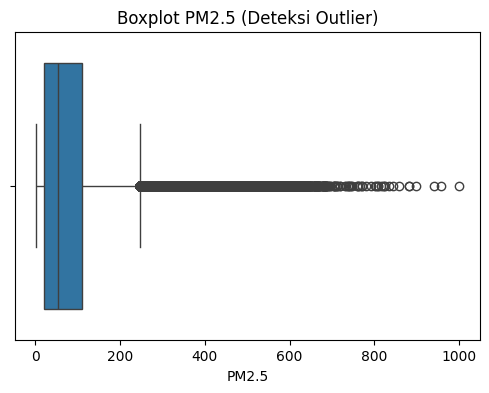

In [5]:
# Cek struktur data
df.info()

# Cek missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Cek duplicate
duplicates = df.duplicated().sum()
print("\nJumlah Duplicate:", duplicates)

# Statistik deskriptif
df.describe()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['PM2.5'])
plt.title("Boxplot PM2.5 (Deteksi Outlier)")
plt.show()

**Steps to Take:**
- Menangani missing values pada variabel numerik menggunakan metode interpolasi dan forward/backward fill agar pola data time-series tetap terjaga.
- Mengisi missing values pada variabel kategorikal (wd) menggunakan modus.
- Menggabungkan kolom waktu (year, month, day, hour) menjadi satu kolom datetime.
- Menghapus kolom yang tidak relevan seperti "No".
- Menangani outlier pada PM2.5 menggunakan metode IQR untuk mengurangi pengaruh nilai ekstrem terhadap analisis.

**Insight:** (Opsional)
- Dataset memiliki beberapa permasalahan utama yaitu missing values dan outlier ekstrem pada PM2.5.
- Outlier yang sangat tinggi dapat mempengaruhi hasil analisis sehingga perlu dilakukan penanganan.
- Dengan dilakukan data cleaning, dataset akan menjadi lebih representatif untuk analisis tren dan hubungan antar variabel.

### Cleaning Data

#### Fixing ... problem

In [6]:
# Handle missing values
num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

df[num_cols] = df[num_cols].interpolate(method='linear')
df[num_cols] = df[num_cols].fillna(method='ffill').fillna(method='bfill')

# Handle missing kategori (wd)
df['wd'].fillna(df['wd'].mode()[0], inplace=True)

# Convert datetime
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])

# Drop kolom tidak penting (No)
df.drop(columns=['No'], inplace=True)

# Cek ulang missing & duplicate
print("Missing setelah cleaning:\n", df.isnull().sum())
print("\nDuplicate setelah cleaning:", df.duplicated().sum())

/tmp/ipykernel_11606/132374201.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_11606/132374201.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['wd'].fillna(df['wd'].mode()[0], inplace=True)


Missing setelah cleaning:
 year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

Duplicate setelah cleaning: 0


**Insight:** (Opsional)
- Seluruh missing values berhasil ditangani menggunakan metode interpolasi serta forward/backward fill, sehingga tidak ada nilai kosong yang tersisa pada dataset.
- Tidak ditemukan data duplikat baik sebelum maupun sesudah proses pembersihan.
- Proses cleaning berhasil mempertahankan jumlah data tanpa perlu menghapus baris secara signifikan, sehingga informasi tetap terjaga.
- Dataset yang telah dibersihkan kini lebih siap untuk analisis time-series dan eksplorasi hubungan antar variabel.

## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:

# --- 1. PM2.5 rata-rata per tahun ---
pm25_year = df.groupby('year')['PM2.5'].mean()

# --- 2. PM2.5 rata-rata per stasiun ---
pm25_station = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

# --- 3. Korelasi variabel cuaca ---
correlation = df[['PM2.5','TEMP','PRES','WSPM']].corr()

print("PM2.5 per tahun:\n", pm25_year)
print("\nPM2.5 per stasiun:\n", pm25_station)
print("\nCorrelation:\n", correlation)

PM2.5 per tahun:
 year
2013    79.768553
2014    86.183671
2015    79.306423
2016    72.078419
2017    92.407898
Name: PM2.5, dtype: float64

PM2.5 per stasiun:
 station
Dongsi           86.144243
Nongzhanguan     85.079472
Wanshouxigong    85.067548
Gucheng          84.074802
Wanliu           83.467612
Guanyuan         82.897522
Aotizhongxin     82.540623
Tiantan          82.033097
Shunyi           79.437962
Changping        70.986438
Huairou          69.501747
Dingling         66.845557
Name: PM2.5, dtype: float64

Correlation:
           PM2.5      TEMP      PRES      WSPM
PM2.5  1.000000 -0.131607  0.019862 -0.271425
TEMP  -0.131607  1.000000 -0.813312  0.032601
PRES   0.019862 -0.813312  1.000000  0.065400
WSPM  -0.271425  0.032601  0.065400  1.000000


**Insight:** (Opsional)
- Rata-rata konsentrasi PM2.5 per tahun menunjukkan fluktuasi selama periode 2013–2017. Nilai tertinggi terjadi pada tahun 2017 (92.41), sedangkan nilai terendah terjadi pada tahun 2016 (72.08). Hal ini menunjukkan bahwa tingkat polusi udara tidak stabil dan mengalami peningkatan signifikan di akhir periode.
- Perbandingan antar stasiun menunjukkan bahwa wilayah seperti Dongsi, Nongzhanguan, dan Wanshouxigong memiliki tingkat PM2.5 tertinggi, sedangkan Dingling dan Huairou memiliki tingkat yang lebih rendah. Hal ini mengindikasikan bahwa polusi udara lebih tinggi di area perkotaan dibandingkan daerah pinggiran.
- Hasil korelasi menunjukkan bahwa kecepatan angin (WSPM) memiliki korelasi negatif paling kuat terhadap PM2.5 (-0.27), yang berarti semakin tinggi kecepatan angin, semakin rendah konsentrasi polusi.
- Suhu (TEMP) juga memiliki korelasi negatif lemah terhadap PM2.5 (-0.13), sedangkan tekanan udara (PRES) hampir tidak memiliki hubungan signifikan terhadap PM2.5.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren PM2.5

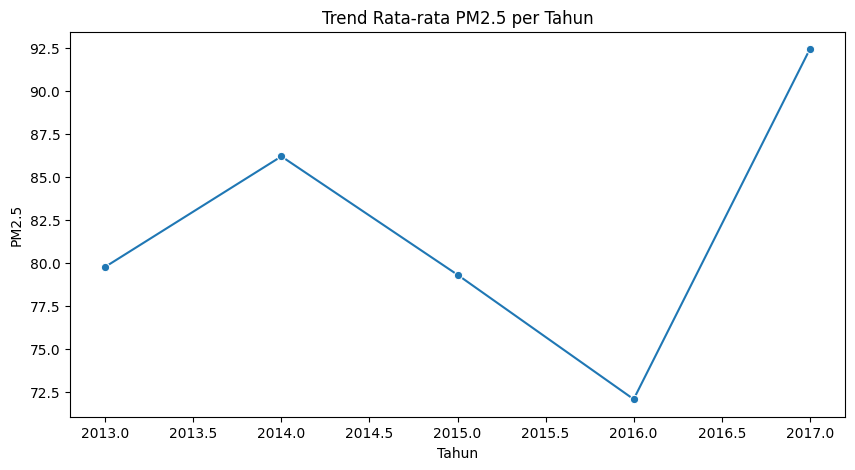

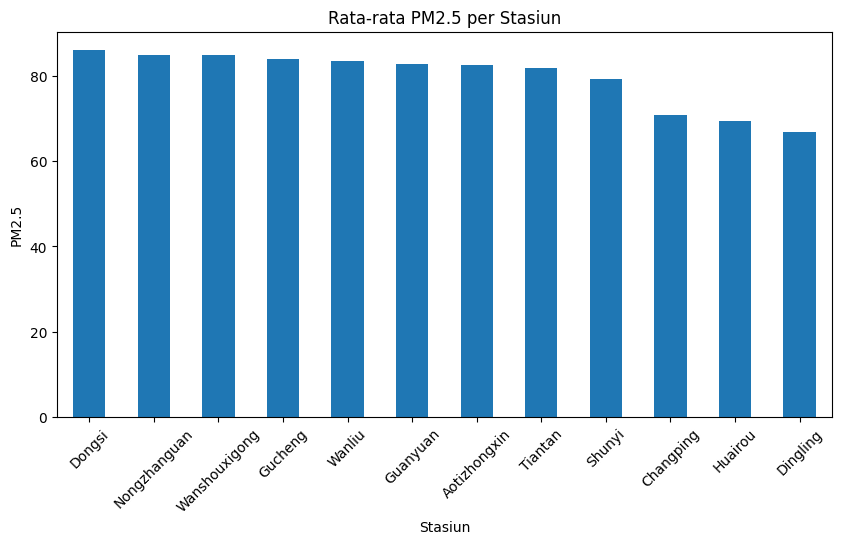

In [13]:
plt.figure(figsize=(10,5))
sns.lineplot(x=pm25_year.index, y=pm25_year.values, marker='o')

plt.title("Trend Rata-rata PM2.5 per Tahun")
plt.xlabel("Tahun")
plt.ylabel("PM2.5")

plt.show()

plt.figure(figsize=(10,5))
pm25_station.plot(kind='bar')

plt.title("Rata-rata PM2.5 per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("PM2.5")

plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2: Pengaruh Cuaca

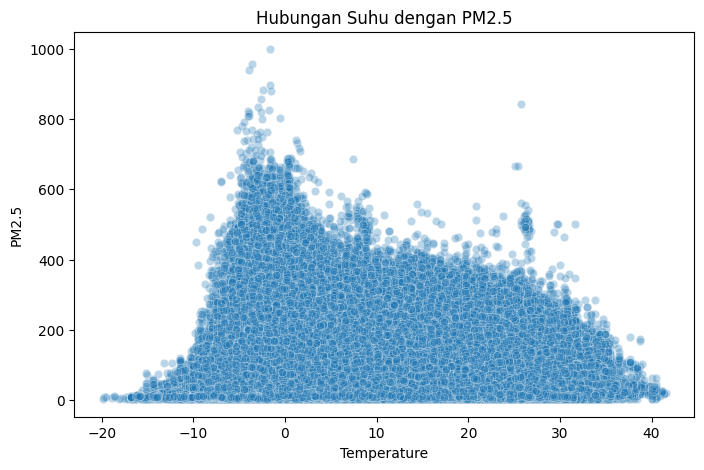

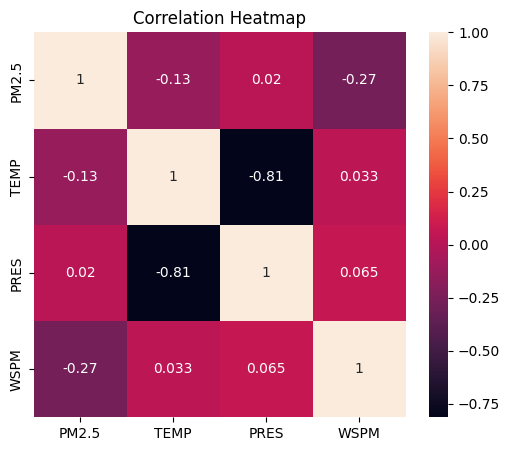

In [14]:

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['TEMP'], y=df['PM2.5'], alpha=0.3)

plt.title("Hubungan Suhu dengan PM2.5")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")

plt.show()


plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insight:** (Opsional)

### Pertanyaan 1 (Tren PM2.5 per Tahun):
- Grafik menunjukkan bahwa rata-rata PM2.5 mengalami fluktuasi selama periode 2013–2017.
- Terjadi peningkatan dari tahun 2013 ke 2014, kemudian penurunan hingga mencapai titik terendah pada tahun 2016.
- Pada tahun 2017 terjadi lonjakan signifikan hingga menjadi nilai tertinggi sepanjang periode.
- Hal ini menunjukkan bahwa kondisi polusi udara tidak konsisten dan cenderung memburuk pada akhir periode pengamatan.
- Selain itu, berdasarkan perbandingan antar stasiun, wilayah seperti Dongsi, Nongzhanguan, dan Wanshouxigong memiliki tingkat PM2.5 yang lebih tinggi dibandingkan stasiun seperti Dingling dan Huairou.
- Hal ini mengindikasikan bahwa wilayah dengan tingkat urbanisasi tinggi cenderung memiliki konsentrasi polusi udara yang lebih tinggi dibandingkan wilayah pinggiran.

### Pertanyaan 2 (Pengaruh Suhu terhadap PM2.5):

- Scatter plot menunjukkan adanya kecenderungan hubungan negatif antara suhu (TEMP) dan PM2.5.
- Konsentrasi PM2.5 cenderung lebih tinggi pada suhu rendah dan menurun seiring peningkatan suhu.
- Namun, sebaran data yang cukup luas menunjukkan bahwa hubungan ini relatif lemah dan masih dipengaruhi oleh faktor lain.
- Hasil korelasi (heatmap) memperkuat temuan tersebut, di mana suhu (TEMP) memiliki korelasi negatif lemah terhadap PM2.5 (-0.13).
- Kecepatan angin (WSPM) memiliki korelasi negatif paling kuat terhadap PM2.5 (-0.27), yang menunjukkan bahwa peningkatan kecepatan angin berkontribusi dalam menurunkan konsentrasi polusi udara.
- Tekanan udara (PRES) memiliki korelasi yang sangat kecil (~0.02), sehingga pengaruhnya terhadap PM2.5 tidak signifikan.
- Selain itu, terdapat korelasi negatif yang kuat antara suhu (TEMP) dan tekanan udara (PRES) (-0.81), yang menunjukkan hubungan terbalik antara kedua variabel tersebut.
- Secara keseluruhan, faktor cuaca memengaruhi variasi PM2.5, dengan kecepatan angin sebagai faktor yang paling berpengaruh, sementara suhu memiliki pengaruh yang lebih lemah.

## Analisis Lanjutan (Opsional)

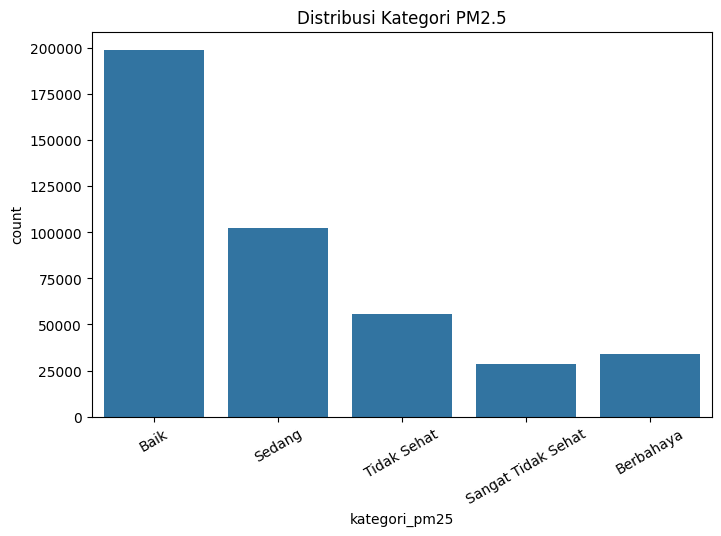

In [15]:
bins = [0, 50, 100, 150, 200, 500]
labels = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']

df['kategori_pm25'] = pd.cut(df['PM2.5'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(x='kategori_pm25', data=df, order=labels)
plt.title("Distribusi Kategori PM2.5")
plt.xticks(rotation=30)
plt.show()

**Insight:**

### Binning:

- Sebagian besar data berada pada kategori Baik dan Sedang, yang menunjukkan bahwa kualitas udara dalam banyak waktu masih berada pada tingkat yang relatif aman.
- Namun, terdapat jumlah yang signifikan pada kategori Tidak Sehat hingga Berbahaya, yang menunjukkan bahwa pada waktu tertentu terjadi lonjakan polusi udara yang dapat membahayakan kesehatan.
- Distribusi ini menunjukkan bahwa meskipun kondisi udara sering berada pada level aman, terdapat risiko polusi ekstrem yang perlu diwaspadai.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata konsentrasi PM2.5 di Beijing selama periode 2013–2017 menunjukkan pola fluktuatif, dengan nilai tertinggi terjadi pada tahun 2017 dan terendah pada tahun 2016. Hal ini menunjukkan bahwa tingkat polusi udara tidak stabil dan cenderung mengalami peningkatan pada akhir periode pengamatan.

- **Conclusion pertanyaan 2:** Variabel cuaca memiliki pengaruh terhadap konsentrasi PM2.5, terutama kecepatan angin (WSPM) yang memiliki korelasi negatif paling kuat. Hal ini menunjukkan bahwa peningkatan kecepatan angin dapat membantu mengurangi tingkat polusi udara. Sementara itu, suhu memiliki pengaruh negatif yang lemah, dan tekanan udara tidak menunjukkan hubungan yang signifikan terhadap PM2.5.

**Rekomendasi Action Item:**
- Pemerintah dapat meningkatkan pengawasan dan kebijakan pengendalian emisi terutama pada periode dengan tren peningkatan polusi, seperti menjelang tahun 2017.
- Mengoptimalkan sistem pemantauan kualitas udara dengan mempertimbangkan faktor cuaca, terutama kecepatan angin, untuk prediksi dan mitigasi polusi.
- Fokus pada wilayah dengan tingkat polusi tinggi seperti Dongsi dan Nongzhanguan untuk implementasi kebijakan lingkungan yang lebih ketat.
- Mengembangkan strategi jangka panjang untuk mengurangi sumber emisi di daerah perkotaan guna menekan tingkat PM2.5.